# Data Preparation and Exploration

This notebook contains the following steps in the data preparation and exploration phase:
1. Data Acquisition
2. Data Examination
3. Data Type Identification
4. Data Cleaning & Quality Improvement
5. Data Transformation for Analysis
6. Data Consolidation

## 1. Data Acquisition

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel('../data/world-cml-2023-v1.xls')
print(df.head())

       country iso2 iso3                      region  wb_econ  minage_fem_leg  \
0  Afghanistan   AF  AFG                  South Asia      1.0             NaN   
1      Albania   AL  ALB       Europe & Central Asia      2.0             5.0   
2      Algeria   DZ  DZA  Middle East & North Africa      2.0             5.0   
3      Andorra   AD  AND       Europe & Central Asia      4.0             5.0   
4       Angola   AO  AGO          Sub-Saharan Africa      2.0             5.0   

   minage_fem_pc  minage_fem_crlaw  minage_fem_any  protect_girl_13  ...  \
0            NaN               NaN             NaN              NaN  ...   
1            5.0               5.0             1.0              3.0  ...   
2            5.0               5.0             1.0              3.0  ...   
3            5.0               5.0             5.0              5.0  ...   
4            2.0               5.0             2.0              5.0  ...   

   minage_par_18_m_2014  minage_par_18_m_2015  minage_pa

## 2. Data Examination

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 85 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   country               193 non-null    str    
 1   iso2                  192 non-null    str    
 2   iso3                  193 non-null    str    
 3   region                193 non-null    str    
 4   wb_econ               192 non-null    float64
 5   minage_fem_leg        192 non-null    float64
 6   minage_fem_pc         192 non-null    float64
 7   minage_fem_crlaw      187 non-null    float64
 8   minage_fem_any        188 non-null    float64
 9   protect_girl_13       187 non-null    float64
 10  protect_girl_15       188 non-null    float64
 11  protect_girl_17       188 non-null    float64
 12  except_crlaw          189 non-null    float64
 13  except_pc             193 non-null    int64  
 14  except_preg           192 non-null    float64
 15  minage_mal_leg        192 non-null

In [4]:
df.shape

(193, 85)

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
pd.set_option('display.max_rows', None)

missing_values = df.isnull().sum()
print(missing_values)

country                  0
iso2                     1
iso3                     0
region                   0
wb_econ                  1
minage_fem_leg           1
minage_fem_pc            1
minage_fem_crlaw         6
minage_fem_any           5
protect_girl_13          6
protect_girl_15          5
protect_girl_17          5
except_crlaw             4
except_pc                0
except_preg              1
minage_mal_leg           1
minage_mal_pc            1
minage_mal_crlaw         6
minage_mal_any           5
protect_boy_13           6
protect_boy_15           6
protect_boy_17           6
legal_diff_leg           1
legal_diff_pc            1
minage_fem_loop          6
minage_mal_loop          6
loop_summ                6
minage_par_18_f_1995    79
minage_par_18_f_1996    79
minage_par_18_f_1997    78
minage_par_18_f_1998    76
minage_par_18_f_1999    76
minage_par_18_f_2000    76
minage_par_18_f_2001    76
minage_par_18_f_2002    75
minage_par_18_f_2003    74
minage_par_18_f_2004    73
m

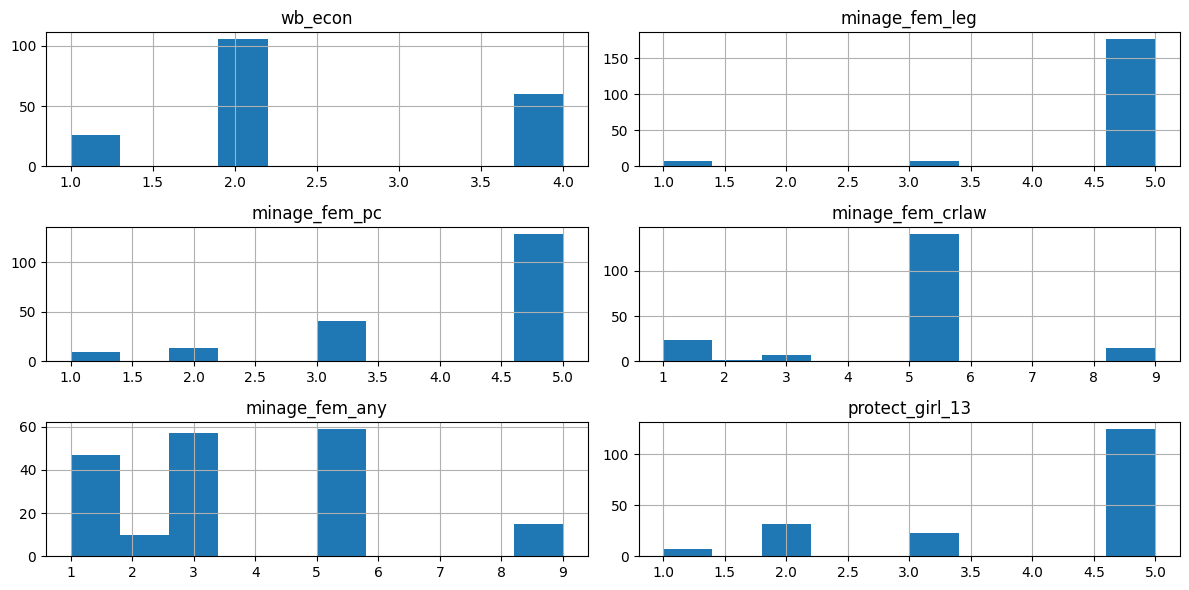

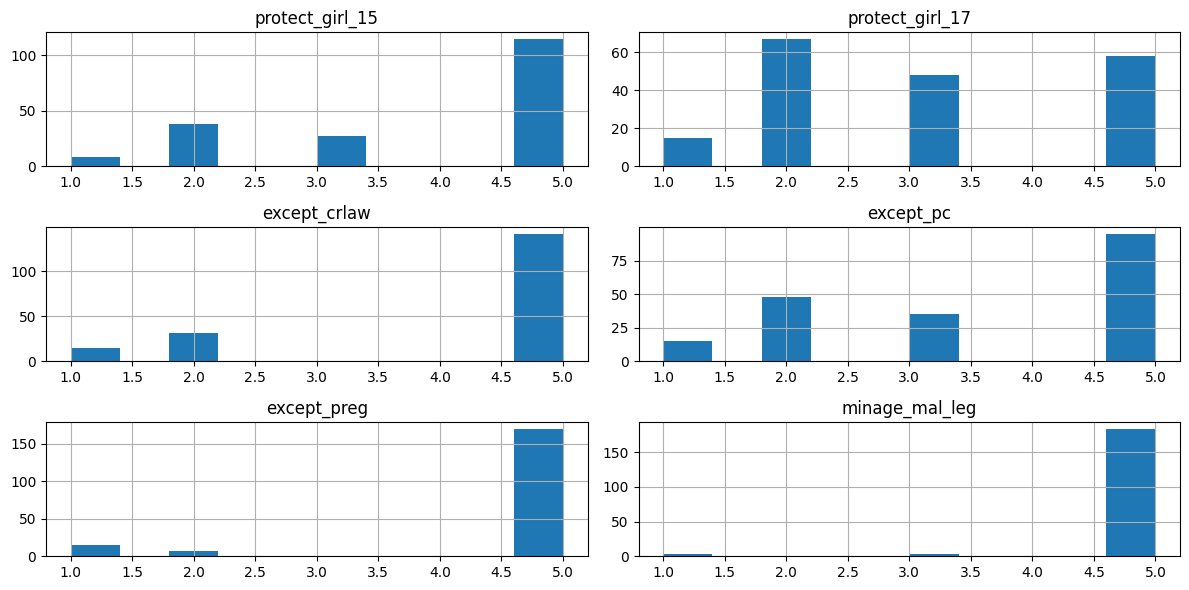

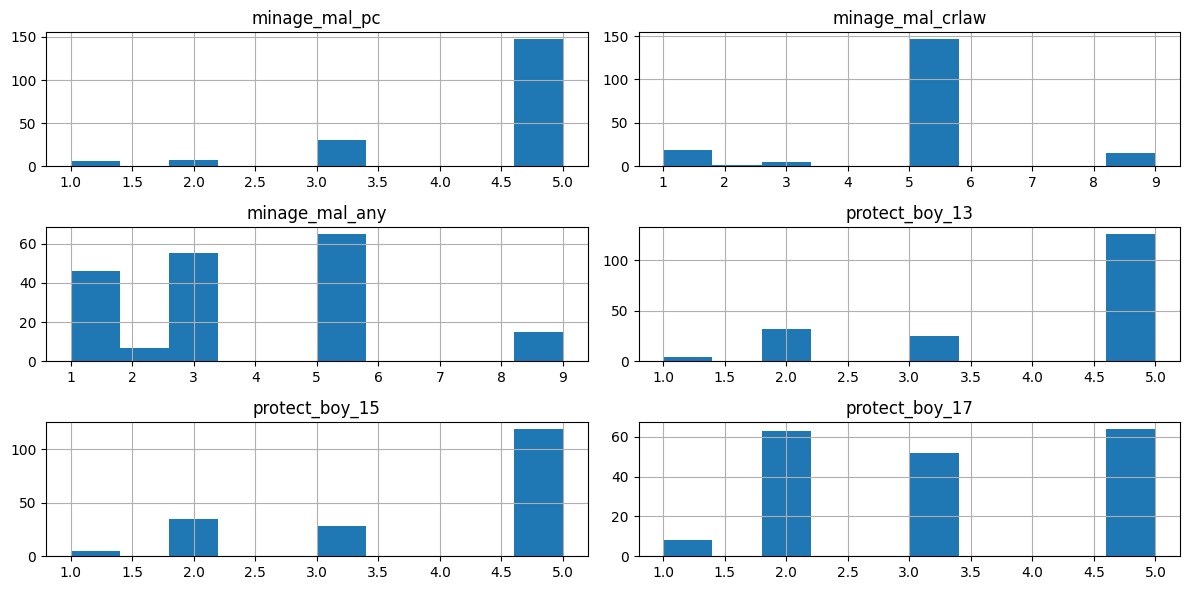

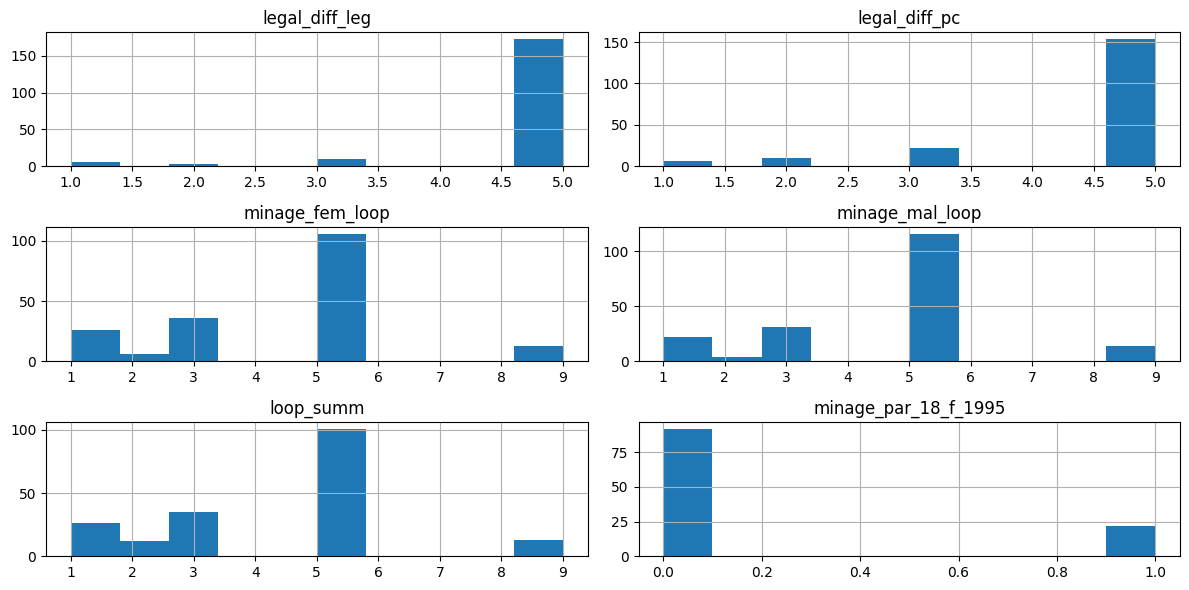

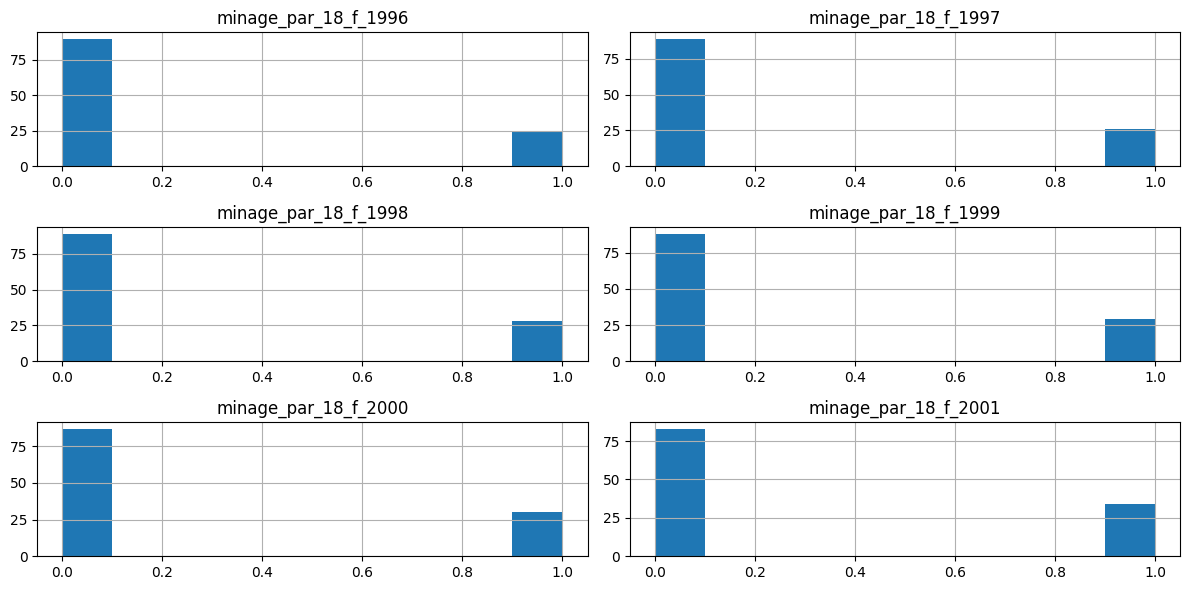

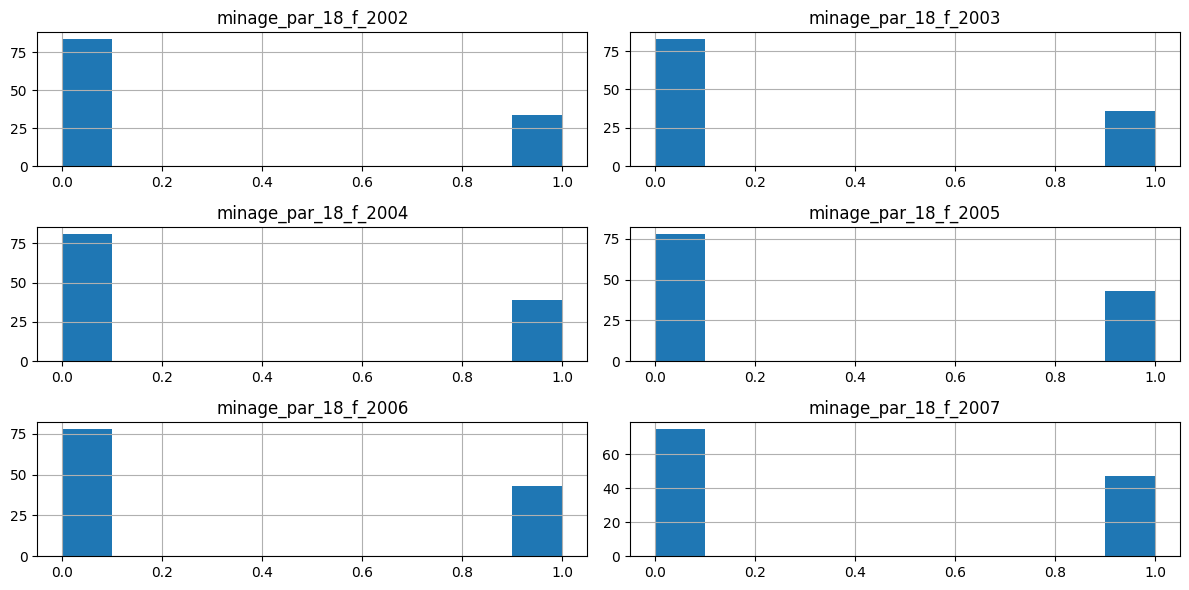

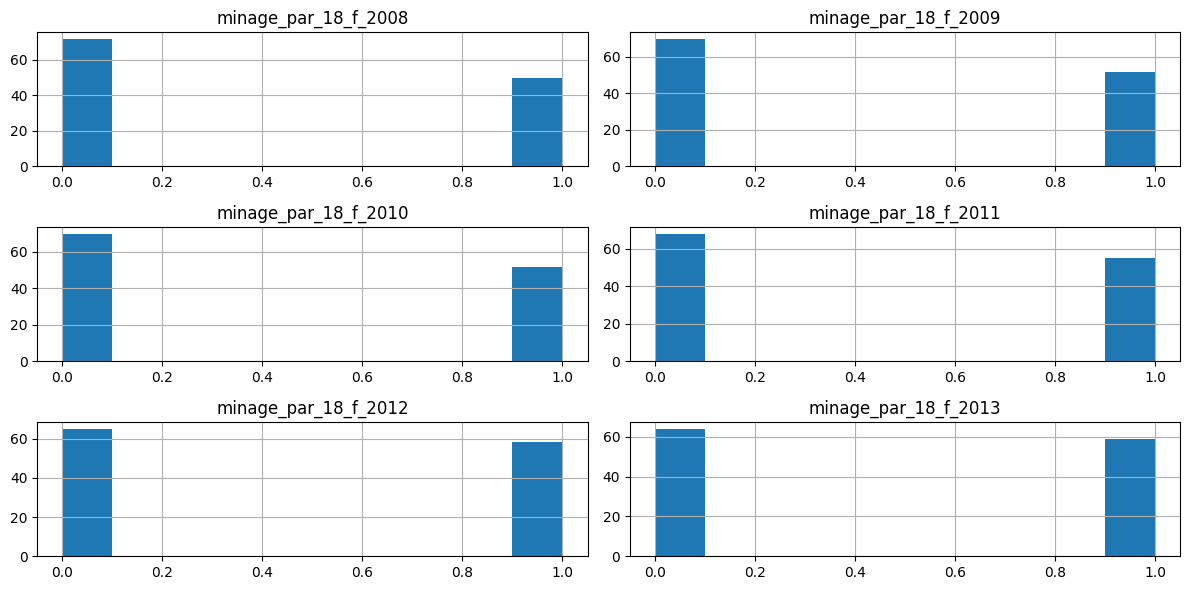

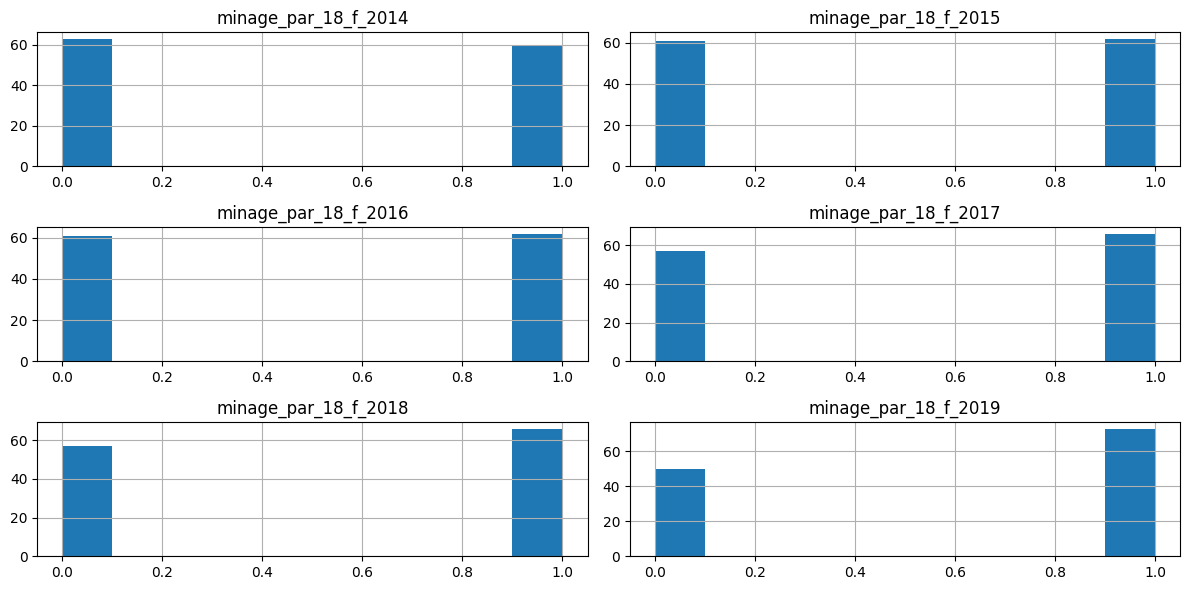

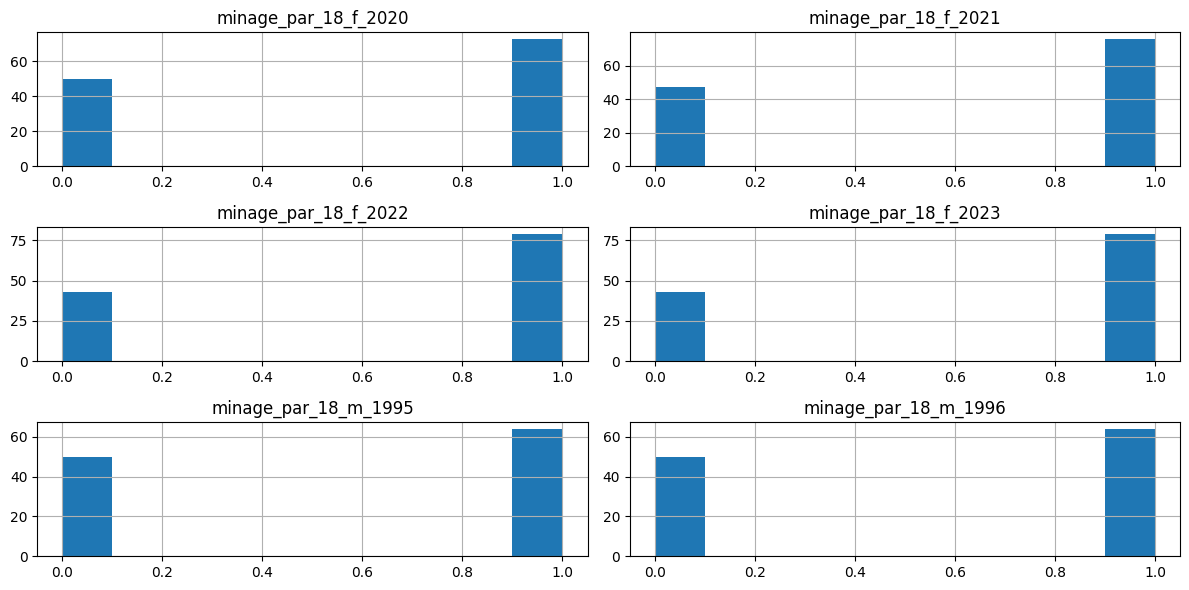

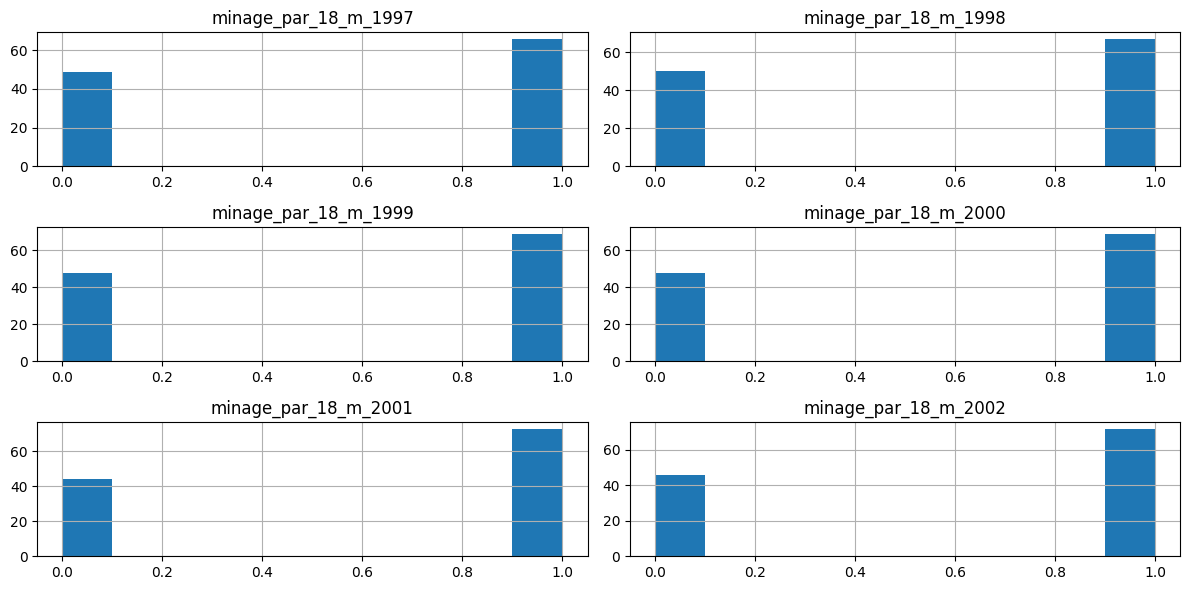

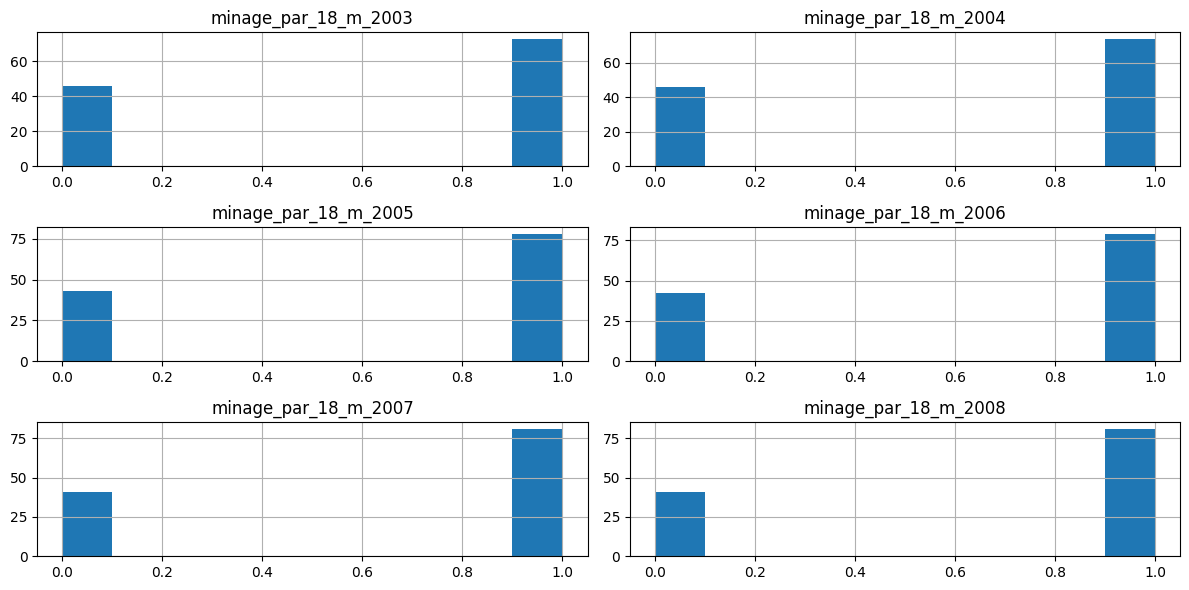

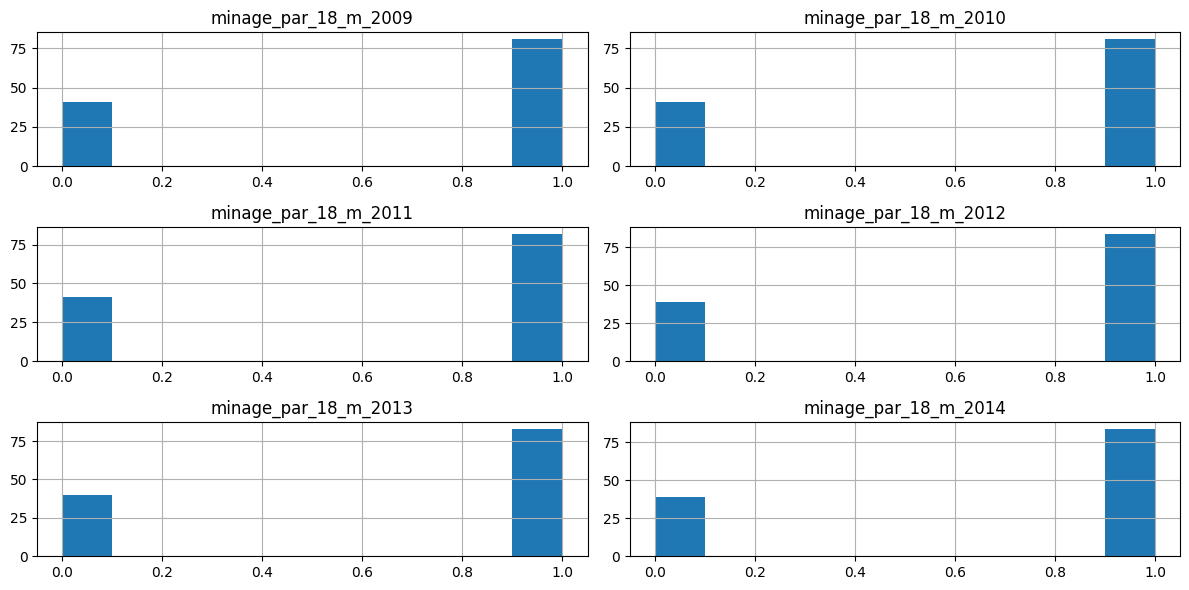

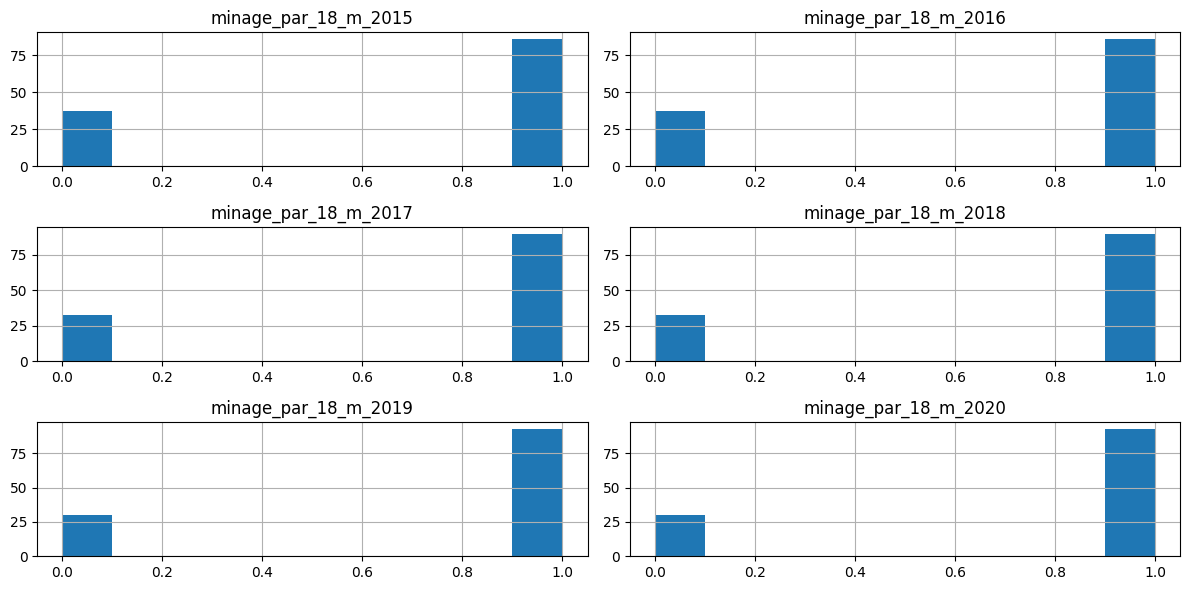

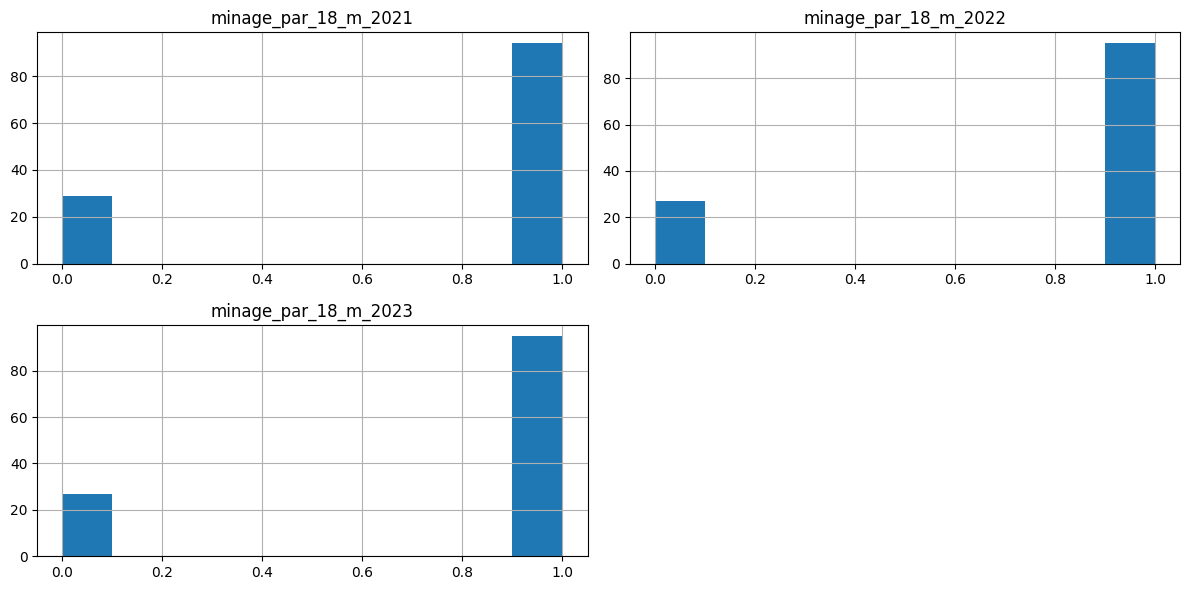

In [7]:
cols = df.select_dtypes(include='number').columns
n = 6

for i in range(0, len(cols), n):
    df[cols[i:i+n]].hist(figsize=(12,6), bins=10)
    plt.tight_layout()
    plt.show()

## 3. Data Type Identification

Pada tahap ini dilakukan identifikasi tipe data setiap variabel dalam dataset untuk memahami struktur fundamental data. Penting untuk membedakan antara **tipe data pandas** (bagaimana data disimpan secara teknis) dan **tipe data visualisasi** (bagaimana data seharusnya diperlakukan dalam analisis dan visualisasi).

Sebagian besar kolom numerik dalam dataset ini sebenarnya adalah **categorical ordinal** yang dikodekan sebagai angka, bukan variabel kuantitatif kontinu. Pemahaman ini krusial agar pemilihan jenis visualisasi nantinya tepat (misalnya: bar chart untuk ordinal, bukan histogram kontinu).

In [8]:
# --- Tipe Data Pandas untuk Kolom Inti (non-timeseries) ---
core_cols = [c for c in df.columns if 'minage_par_18' not in c]
print("=== Tipe Data Pandas (Kolom Inti) ===")
print(df[core_cols].dtypes.to_string())
print()

# --- Pemetaan Tipe Data Visualisasi ---
type_mapping = {
    # Identitas negara — Categorical (Nominal)
    'country':          ('Categorical (nominal)', 'Nama negara'),
    'iso2':             ('Categorical (nominal)', 'Kode ISO 3166-1 alpha-2'),
    'iso3':             ('Categorical (nominal)', 'Kode ISO 3166-1 alpha-3'),
    'region':           ('Categorical (nominal)', 'Klasifikasi regional World Bank'),

    # Klasifikasi ekonomi — Categorical (Ordinal)
    'wb_econ':          ('Categorical (ordinal)', '1=Low, 2=Middle, 4=High income'),

    # Usia minimum pernikahan perempuan — Categorical (Ordinal)
    'minage_fem_leg':   ('Categorical (ordinal)', 'Skala usia: 1=≤13, 2=14-15, 3=16-17, 5=≥18'),
    'minage_fem_pc':    ('Categorical (ordinal)', 'Skala usia: 1=≤13, 2=14-15, 3=16-17, 5=≥18'),
    'minage_fem_crlaw': ('Categorical (ordinal)', 'Skala usia: 1=≤13, 2=14-15, 3=16-17, 5=≥18, 9=Unknown'),
    'minage_fem_any':   ('Categorical (ordinal)', 'Skala usia: 1=≤13, 2=14-15, 3=16-17, 5=≥18, 9=Unknown'),
    'minage_fem_loop':  ('Categorical (ordinal)', 'Skala usia: 1=≤13, 2=14-15, 3=16-17, 5=≥18, 9=Unknown'),

    # Usia minimum pernikahan laki-laki — Categorical (Ordinal)
    'minage_mal_leg':   ('Categorical (ordinal)', 'Skala usia: 1=≤13, 2=14-15, 3=16-17, 5=≥18'),
    'minage_mal_pc':    ('Categorical (ordinal)', 'Skala usia: 1=≤13, 2=14-15, 3=16-17, 5=≥18'),
    'minage_mal_crlaw': ('Categorical (ordinal)', 'Skala usia: 1=≤13, 2=14-15, 3=16-17, 5=≥18, 9=Unknown'),
    'minage_mal_any':   ('Categorical (ordinal)', 'Skala usia: 1=≤13, 2=14-15, 3=16-17, 5=≥18, 9=Unknown'),
    'minage_mal_loop':  ('Categorical (ordinal)', 'Skala usia: 1=≤13, 2=14-15, 3=16-17, 5=≥18, 9=Unknown'),

    # Perlindungan anak perempuan — Categorical (Ordinal)
    'protect_girl_13':  ('Categorical (ordinal)', '1=Tanpa batasan, 2=Consent ortu, 3=Persetujuan pengadilan, 5=Dilarang'),
    'protect_girl_15':  ('Categorical (ordinal)', '1=Tanpa batasan, 2=Consent ortu, 3=Persetujuan pengadilan, 5=Dilarang'),
    'protect_girl_17':  ('Categorical (ordinal)', '1=Tanpa batasan, 2=Consent ortu, 3=Persetujuan pengadilan, 5=Dilarang'),

    # Perlindungan anak laki-laki — Categorical (Ordinal)
    'protect_boy_13':   ('Categorical (ordinal)', '1=Tanpa batasan, 2=Consent ortu, 3=Persetujuan pengadilan, 5=Dilarang'),
    'protect_boy_15':   ('Categorical (ordinal)', '1=Tanpa batasan, 2=Consent ortu, 3=Persetujuan pengadilan, 5=Dilarang'),
    'protect_boy_17':   ('Categorical (ordinal)', '1=Tanpa batasan, 2=Consent ortu, 3=Persetujuan pengadilan, 5=Dilarang'),

    # Pengecualian hukum — Categorical (Ordinal)
    'except_crlaw':     ('Categorical (ordinal)', 'Pengecualian hukum adat/agama'),
    'except_pc':        ('Categorical (ordinal)', '1=Tanpa syarat, 2=Consent ortu, 3=+syarat tambahan, 5=Tidak ada'),
    'except_preg':      ('Categorical (ordinal)', 'Pengecualian terkait kehamilan'),

    # Perbedaan gender dalam hukum — Numerical (discrete)
    'legal_diff_leg':   ('Numerical (discrete)', 'Selisih usia legal perempuan vs laki-laki'),
    'legal_diff_pc':    ('Numerical (discrete)', 'Selisih usia parental consent perempuan vs laki-laki'),

    # Ringkasan loophole — Categorical (Ordinal)
    'loop_summ':        ('Categorical (ordinal)', 'Ringkasan loophole: skala usia + 9=Unknown'),
}

# Tambahkan kolom timeseries
ts_cols = [c for c in df.columns if 'minage_par_18' in c]
for col in ts_cols:
    type_mapping[col] = ('Binary (temporal)', '0=Tidak, 1=Ya — usia min ≥18 per tahun')

# Tampilkan tabel ringkasan untuk kolom inti
print("=== Pemetaan Tipe Data Visualisasi (Kolom Inti) ===")
print(f"{'Kolom':<22} {'Tipe Pandas':<12} {'Tipe Visualisasi':<28} {'Keterangan'}")
print('-' * 110)
for col in core_cols:
    pandas_type = str(df[col].dtype)
    vis_type, desc = type_mapping.get(col, ('Unknown', ''))
    print(f"{col:<22} {pandas_type:<12} {vis_type:<28} {desc}")

print()

# --- Ringkasan per tipe visualisasi ---
from collections import Counter
vis_types = Counter()
for col in df.columns:
    vis_type, _ = type_mapping.get(col, ('Unknown', ''))
    vis_types[vis_type] += 1

print("=== Ringkasan Jumlah Kolom per Tipe Visualisasi ===")
for vtype, count in vis_types.most_common():
    print(f"  {vtype}: {count} kolom")

=== Tipe Data Pandas (Kolom Inti) ===
country                 str
iso2                    str
iso3                    str
region                  str
wb_econ             float64
minage_fem_leg      float64
minage_fem_pc       float64
minage_fem_crlaw    float64
minage_fem_any      float64
protect_girl_13     float64
protect_girl_15     float64
protect_girl_17     float64
except_crlaw        float64
except_pc             int64
except_preg         float64
minage_mal_leg      float64
minage_mal_pc       float64
minage_mal_crlaw    float64
minage_mal_any      float64
protect_boy_13      float64
protect_boy_15      float64
protect_boy_17      float64
legal_diff_leg      float64
legal_diff_pc       float64
minage_fem_loop     float64
minage_mal_loop     float64
loop_summ           float64

=== Pemetaan Tipe Data Visualisasi (Kolom Inti) ===
Kolom                  Tipe Pandas  Tipe Visualisasi             Keterangan
-----------------------------------------------------------------------------

## 4. Data Cleaning & Quality Improvement

Berdasarkan temuan dari eksplorasi data di bagian sebelumnya, berikut adalah langkah-langkah pembersihan data:

1. **Fix `iso2` Namibia**: Kode ISO-2 Namibia ("NA") terparse sebagai NaN oleh pandas. Diperbaiki secara manual.
2. **Missing values lainnya dipertahankan** karena bersifat legitimate (bukan error):
   - `wb_econ` Venezuela: World Bank tidak mengklasifikasikan Venezuela
   - `minage_fem_leg/pc` Afghanistan: Tidak ada data legislasi
   - Kolom `crlaw`/`loop` (6 negara: Afghanistan, Comoros, Ethiopia, Iraq, Myanmar, Tanzania): Sistem hukum kompleks yang sulit dikodekan
   - `except_crlaw` (4 negara): Sama dengan poin di atas
   - Kolom timeseries (~70-79 missing per kolom): Data historis tidak tersedia untuk semua negara
3. **Nilai 9** ("Unknown minimum age set by religious/customary law") **bukan** missing data, melainkan kategori bermakna yang dipertahankan sebagai kode tersendiri.
4. **Tidak ada duplikasi** baris maupun nama negara.

In [9]:
# --- Ringkasan Missing Values pada Kolom Inti ---
core_cols = [c for c in df.columns if 'minage_par_18' not in c]
missing_core = df[core_cols].isnull().sum()
missing_core = missing_core[missing_core > 0]

print("=== Missing Values pada Kolom Inti ===")
for col, count in missing_core.items():
    countries = df[df[col].isnull()]['country'].tolist()
    print(f"  {col} ({count} missing): {', '.join(countries)}")
print()

# --- Fix iso2 Namibia ---
print("=== Fix: iso2 Namibia ===")
print(f"Sebelum: {df.loc[df['country'] == 'Namibia', 'iso2'].values[0]}")
df.loc[df['country'] == 'Namibia', 'iso2'] = 'NA'
print(f"Sesudah: {df.loc[df['country'] == 'Namibia', 'iso2'].values[0]}")
print()

# --- Negara dengan Value 9 (Unknown/Unregulated) ---
value9_cols = ['minage_fem_crlaw', 'minage_fem_any', 'minage_mal_crlaw',
               'minage_mal_any', 'minage_fem_loop', 'minage_mal_loop', 'loop_summ']

print("=== Negara dengan Nilai 9 (Unknown minimum age - religious/customary law) ===")
for col in value9_cols:
    countries_9 = df[df[col] == 9]['country'].tolist()
    print(f"  {col} ({len(countries_9)} negara): {', '.join(countries_9)}")
print()

# --- Konfirmasi Tidak Ada Duplikat ---
print("=== Pemeriksaan Duplikasi ===")
print(f"Baris duplikat: {df.duplicated().sum()}")
print(f"Nama negara duplikat: {df['country'].duplicated().sum()}")
print()

# --- Dokumentasi Keputusan ---
print("=== Dokumentasi Keputusan ===")
print("1. iso2 Namibia        → FIXED (diisi 'NA')")
print("2. wb_econ Venezuela   → DIPERTAHANKAN NaN (tidak diklasifikasikan World Bank)")
print("3. minage Afghanistan  → DIPERTAHANKAN NaN (tidak ada data legislasi)")
print("4. Kolom crlaw/loop    → DIPERTAHANKAN NaN (sistem hukum kompleks)")
print("5. Kolom timeseries    → DIPERTAHANKAN NaN (data historis tidak tersedia)")
print("6. Nilai 9             → DIPERTAHANKAN (kategori bermakna, bukan missing)")

=== Missing Values pada Kolom Inti ===
  iso2 (1 missing): Namibia
  wb_econ (1 missing): Venezuela
  minage_fem_leg (1 missing): Afghanistan
  minage_fem_pc (1 missing): Afghanistan
  minage_fem_crlaw (6 missing): Afghanistan, Comoros, Ethiopia, Iraq, Myanmar, Tanzania
  minage_fem_any (5 missing): Afghanistan, Ethiopia, Iraq, Myanmar, Tanzania
  protect_girl_13 (6 missing): Afghanistan, Comoros, Ethiopia, Iraq, Myanmar, Tanzania
  protect_girl_15 (5 missing): Afghanistan, Comoros, Ethiopia, Iraq, Myanmar
  protect_girl_17 (5 missing): Afghanistan, Comoros, Ethiopia, Iraq, Myanmar
  except_crlaw (4 missing): Afghanistan, Comoros, Ethiopia, Myanmar
  except_preg (1 missing): Afghanistan
  minage_mal_leg (1 missing): Afghanistan
  minage_mal_pc (1 missing): Afghanistan
  minage_mal_crlaw (6 missing): Afghanistan, Comoros, Ethiopia, Iraq, Myanmar, Tanzania
  minage_mal_any (5 missing): Afghanistan, Ethiopia, Iraq, Myanmar, Tanzania
  protect_boy_13 (6 missing): Afghanistan, Comoros, Ethi

Baris duplikat: 0
Nama negara duplikat: 0

=== Dokumentasi Keputusan ===
1. iso2 Namibia        → FIXED (diisi 'NA')
2. wb_econ Venezuela   → DIPERTAHANKAN NaN (tidak diklasifikasikan World Bank)
3. minage Afghanistan  → DIPERTAHANKAN NaN (tidak ada data legislasi)
4. Kolom crlaw/loop    → DIPERTAHANKAN NaN (sistem hukum kompleks)
5. Kolom timeseries    → DIPERTAHANKAN NaN (data historis tidak tersedia)
6. Nilai 9             → DIPERTAHANKAN (kategori bermakna, bukan missing)


## 5. Data Transformation for Analysis

Pada bagian ini dibuat kolom-kolom turunan baru untuk mempermudah analisis dan visualisasi:

1. **`wb_econ_label`**: Label readable untuk klasifikasi ekonomi World Bank (Low-income / Middle-income / High-income)
2. **`has_loophole_fem`** & **`has_loophole_mal`**: Boolean — apakah ada celah hukum (loophole) yang menurunkan usia minimum pernikahan di bawah usia legal
3. **`loophole_severity_fem`**: Tingkat keparahan loophole untuk perempuan (Ringan / Sedang / Berat / Unknown)
4. **`gender_loophole_gap`**: Selisih perlindungan hukum antara perempuan dan laki-laki (negatif = perempuan kurang terlindungi)
5. **Label mapping** untuk kolom ordinal (`minage_*`, `protect_*`, `except_pc`) agar nilai numerik lebih mudah dibaca

**Resolusi data**: Analisis menggunakan data cross-sectional (snapshot 2023) pada level negara. Kolom timeseries (`minage_par_18_f/m_*`) tersedia untuk analisis tren temporal di tahap selanjutnya.

In [10]:
# --- 5a. Label Ekonomi World Bank ---
wb_econ_map = {1.0: 'Low-income', 2.0: 'Middle-income', 4.0: 'High-income'}
df['wb_econ_label'] = df['wb_econ'].map(wb_econ_map)

print("=== Distribusi wb_econ_label ===")
print(df['wb_econ_label'].value_counts(dropna=False))
print()

# --- 5b. Deteksi Loophole ---
# CATATAN: Ketika minage_*_loop = 9 (Unknown religious/customary), boolean
# akan False karena `9 < leg` dievaluasi angka mentah. Ini adalah pilihan
# sadar — "unknown" tidak dihitung sebagai loophole sampai ada kepastian.
# Kategori Unknown ditangani terpisah di kolom loophole_severity_fem.
df['has_loophole_fem'] = df['minage_fem_loop'] < df['minage_fem_leg']
df['has_loophole_mal'] = df['minage_mal_loop'] < df['minage_mal_leg']

print("=== Deteksi Loophole ===")
print(f"Negara dengan loophole (perempuan): {df['has_loophole_fem'].sum()}")
print(f"Negara dengan loophole (laki-laki): {df['has_loophole_mal'].sum()}")
print()

# --- 5c. Severity Loophole Perempuan ---
# FIX: severity dikategorikan berdasarkan nilai `loop` langsung saat loop < leg,
# tidak bergantung pada `leg == 5`. Sebelumnya ada 2 negara loophole yang
# leg-nya bukan 5 (Bahamas, Tonga dengan leg=2, loop juga rendah) yang salah
# diklasifikasi sebagai "Tidak ada loophole" walau has_loophole=True.
def classify_loophole_severity(row):
    loop = row['minage_fem_loop']
    leg = row['minage_fem_leg']
    if pd.isna(loop) or pd.isna(leg):
        return None
    if loop == 9:
        return 'Unknown'
    if loop >= leg:
        return 'Tidak ada loophole'
    # loop < leg → ada loophole; severity ditentukan oleh nilai loop
    if loop == 3:    # Loophole efektif ke 16-17
        return 'Ringan'
    elif loop == 2:  # Loophole efektif ke 14-15
        return 'Sedang'
    elif loop == 1:  # Loophole efektif ke ≤13
        return 'Berat'
    return 'Tidak ada loophole'  # fallback defensif

df['loophole_severity_fem'] = df.apply(classify_loophole_severity, axis=1)

print("=== Distribusi Severity Loophole (Perempuan) ===")
print(df['loophole_severity_fem'].value_counts(dropna=False))
print()

# --- 5d. Gender Loophole Gap ---
# FIX: ketika minage_fem_loop atau minage_mal_loop = 9 (Unknown), selisih
# aritmatika tidak bermakna (mis. 9 − 5 = 4 tidak merefleksikan ketidaksetaraan).
# Nilai 9 di-mask jadi NaN sebelum pengurangan.
fem_loop_clean = df['minage_fem_loop'].where(df['minage_fem_loop'] != 9)
mal_loop_clean = df['minage_mal_loop'].where(df['minage_mal_loop'] != 9)
df['gender_loophole_gap'] = fem_loop_clean - mal_loop_clean

print("=== Gender Loophole Gap (negatif = perempuan kurang terlindungi) ===")
print(df['gender_loophole_gap'].value_counts(dropna=False).sort_index())
print()

# --- 5e. Label Mapping Kolom Ordinal ---
# Mapping minage_*
minage_map = {1: '≤13', 2: '14-15', 3: '16-17', 5: '≥18', 9: 'Unknown'}
minage_cols = ['minage_fem_leg', 'minage_fem_pc', 'minage_fem_crlaw', 'minage_fem_any',
               'minage_mal_leg', 'minage_mal_pc', 'minage_mal_crlaw', 'minage_mal_any',
               'minage_fem_loop', 'minage_mal_loop']
for col in minage_cols:
    df[f'{col}_label'] = df[col].map(minage_map)

# Mapping protect_*
protect_map = {1: 'Tanpa batasan', 2: 'Consent ortu/hukum adat',
               3: 'Persetujuan pengadilan/kehamilan', 5: 'Dilarang'}
protect_cols = ['protect_girl_13', 'protect_girl_15', 'protect_girl_17',
                'protect_boy_13', 'protect_boy_15', 'protect_boy_17']
for col in protect_cols:
    df[f'{col}_label'] = df[col].map(protect_map)

# Mapping except_pc
except_pc_map = {1: 'Bisa menikah <18 tanpa syarat', 2: 'Ada pengecualian consent ortu',
                 3: 'Ada pengecualian + syarat tambahan', 5: 'Tidak ada pengecualian'}
df['except_pc_label'] = df['except_pc'].map(except_pc_map)

print("=== Contoh Hasil Label Mapping ===")
sample_cols = ['country', 'minage_fem_leg_label', 'minage_fem_loop_label',
               'protect_girl_13_label', 'except_pc_label']
print(df[sample_cols].head(10).to_string())
print()

# --- 5f. Resolusi Data ---
ts_cols = [c for c in df.columns if 'minage_par_18' in c]
print("=== Resolusi Data ===")
print(f"Data cross-sectional (snapshot 2023) pada level negara")
print(f"Kolom timeseries tersedia: {len(ts_cols)} kolom")
print(f"Kolom cross-sectional + turunan: {len(df.columns) - len(ts_cols)} kolom")
print()

# --- Ringkasan Statistik ---
print("=== Ringkasan Statistik Transformasi ===")
print(f"Total negara: {len(df)}")
print(f"Negara dengan loophole (perempuan): {df['has_loophole_fem'].sum()}")
print(f"Negara dengan loophole (laki-laki): {df['has_loophole_mal'].sum()}")
print(f"\nDistribusi severity loophole perempuan:")
for val, count in df['loophole_severity_fem'].value_counts(dropna=False).items():
    print(f"  {val}: {count}")

# Validasi konsistensi: total has_loophole_fem harus sama dengan
# jumlah severity (Ringan + Sedang + Berat), karena Unknown excluded
sev_sum = df['loophole_severity_fem'].isin(['Ringan', 'Sedang', 'Berat']).sum()
print(f"\nValidasi: has_loophole_fem={df['has_loophole_fem'].sum()} | "
      f"Ringan+Sedang+Berat={sev_sum} (harus sama)")

print(f"\nJumlah kolom baru: {len(df.columns) - 85}")
print(f"Total kolom sekarang: {len(df.columns)}")

=== Distribusi wb_econ_label ===
wb_econ_label
Middle-income    106
High-income       60
Low-income        26
NaN                1
Name: count, dtype: int64

=== Deteksi Loophole ===
Negara dengan loophole (perempuan): 55
Negara dengan loophole (laki-laki): 50

=== Distribusi Severity Loophole (Perempuan) ===
loophole_severity_fem
Tidak ada loophole    119
Ringan                 31
Berat                  19
Unknown                13
NaN                     6
Sedang                  5
Name: count, dtype: int64

=== Gender Loophole Gap (negatif = perempuan kurang terlindungi) ===
gender_loophole_gap
-4.0      1
-3.0      1
-2.0      8
-1.0      5
 0.0    158
 NaN     20
Name: count, dtype: int64

=== Contoh Hasil Label Mapping ===
               country minage_fem_leg_label minage_fem_loop_label             protect_girl_13_label                     except_pc_label
0          Afghanistan                  NaN                   NaN                               NaN              Tidak ada pe

## 6. Data Consolidation

Pada tahap ini, diputuskan bahwa **tidak diperlukan konsolidasi data eksternal tambahan**. Alasan:

- Dataset sudah mengandung variabel `wb_econ` (World Bank Income Group) sebagai proksi kondisi ekonomi negara
- Dataset sudah mengandung variabel `region` (klasifikasi geografis World Bank)
- Kedua variabel ini cukup untuk analisis perbandingan berdasarkan kelompok pendapatan dan wilayah
- Menambahkan data GDP per capita secara eksplisit tidak diperlukan karena `wb_econ` sudah merepresentasikan klasifikasi ekonomi yang relevan

Di akhir bagian ini, dataset final yang sudah dibersihkan dan ditransformasi diekspor ke CSV.

In [11]:
# --- Distribusi variabel yang sudah tersedia untuk analisis perbandingan ---
print("=== Distribusi Klasifikasi Ekonomi (wb_econ) ===")
print(df['wb_econ_label'].value_counts(dropna=False))
print()

print("=== Distribusi Region ===")
print(df['region'].value_counts())
print()

print("Kesimpulan: Konsolidasi data eksternal tidak diperlukan.")
print("Variabel wb_econ dan region sudah cukup untuk analisis perbandingan.")
print()

# --- Export Dataset Final ---
output_path = '../data/world-cml-2023-cleaned.csv'
df.to_csv(output_path, index=False)

print("=== Dataset Final Diekspor ===")
print(f"Path: {output_path}")
print(f"Shape: {df.shape}")
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")

=== Distribusi Klasifikasi Ekonomi (wb_econ) ===
wb_econ_label
Middle-income    106
High-income       60
Low-income        26
NaN                1
Name: count, dtype: int64

=== Distribusi Region ===
region
Europe & Central Asia         53
Sub-Saharan Africa            48
Americas                      35
East Asia & Pacific           30
Middle East & North Africa    19
South Asia                     8
Name: count, dtype: int64

Kesimpulan: Konsolidasi data eksternal tidak diperlukan.
Variabel wb_econ dan region sudah cukup untuk analisis perbandingan.



=== Dataset Final Diekspor ===
Path: ../data/world-cml-2023-cleaned.csv
Shape: (193, 107)
Jumlah baris: 193
Jumlah kolom: 107
